In [19]:
import datetime, calendar, glob, os, pickle

import pickle as pkl
import geopandas as gpd
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy.stats as stats
import seaborn as sns

from skfda.representation.basis import Fourier, BSpline
from skfda.exploratory.depth import ModifiedBandDepth, IntegratedDepth
from skfda import FDataGrid

from statsmodels.distributions.empirical_distribution import ECDF

from sklearn.neighbors import KernelDensity

from matplotlib import cm
#from matplotlib_scalebar.scalebar import ScaleBar
from matplotlib.transforms import ScaledTranslation

from scipy.integrate import quad
from scipy.stats import multivariate_normal, norm
from scipy.integrate import cumulative_trapezoid  

from sklearn.neighbors import KernelDensity

from statsmodels.distributions.empirical_distribution import ECDF

from functional_utils import (_fDepth, 
                              _fQuantile, 
                              _bootstrap_fDepth,
                              _bootrapped_confidence_bands_from_fDepth,
                              _confidence_bands_from_fDepth, 
                              _confidence_bands_from_eCDF)

from ffc_utils import (_fknn_forecast_dynamic_update, 
                       _haversine_dist, 
                       _silverman_rule)

plt.rcParams["legend.handlelength"] = 1
plt.rcParams["legend.handleheight"] = 1.125
#plt.rcParams["font.family"]         = "Avenir"

path_to_fDepth     = '/home/gterren/dynamic_update/functional_forecast_dynamic_update/fDepth'
path_to_data       = '/home/gterren/dynamic_update/data'
path_to_validation = '/home/gterren/dynamic_update/validation'
path_to_params     = '/home/gterren/dynamic_update/params'
path_to_images     = "/home/gterren/dynamic_update/images"
path_to_ensambles  = "/home/gterren/dynamic_update/ensambles"

# Loading color palette
palette_ = pd.read_csv(path_to_data + "/palette.csv")
print(palette_)

# Loading Texas map
TX_ = gpd.read_file(path_to_data + "/maps/TX/State.shp")

      miro      ibm
0  #013396  #648FFF
1  #B1C06E  #785EF0
2  #056534  #DC267F
3  #F80202  #FE6100
4  #FDD906  #FFB000
5  #FCF795      NaN
6  #CCEDFF      NaN
7  #FDD60B      NaN
8  #FCE9D0      NaN


In [20]:
resource    = 'wind'
method      = 'fusion'
description = 'val'

with open(path_to_ensambles + f'/{resource}-{method}-{description}-test_ffc.pkl', "rb") as f:
    _ensambles = pickle.load(f)

In [21]:
# from sklearn.linear_model import LinearRegression

# Y_true_ = []
# Y_med_  = []

# for asset in _ensambles.keys():
#     print(asset, len(_ensambles[asset].keys()))
#     for day in _ensambles[asset].keys():
#         y_true_, Y_ensambles_ = _ensambles[asset][day]
#         y_med_ = np.mean(Y_ensambles_, axis = 0)

#         Y_true_.append(y_true_)
#         Y_med_.append(y_med_)   

# Y_true_ = np.stack(Y_true_)
# Y_med_  = np.stack(Y_med_)
# print(Y_true_.shape, Y_med_.shape)

# Y_med_ = np.concatenate([Y_med_.flatten()[:, np.newaxis]**2, Y_med_.flatten()[:, np.newaxis]], axis=1)
# print(Y_med_.shape)
# _model = LinearRegression().fit(Y_med_, Y_true_.flatten()[:, np.newaxis])
# print( _model.coef_)    
# # adjust each ensemble member by same transformation
# a = _model.coef_[0][1]      # slope
# b = _model.coef_[0][0]      # slope
# c = _model.intercept_    # intercept

In [ ]:
# def _KDE_PIT(y_true_, Y_ensembles_):
#     """
#     y_true_       : array-like shape (T,)         # one truth per lead time / case
#     Y_ensembles_  : array-like shape (N, T)       # N ensemble members, T times
#     returns       : PIT values, shape (T,)
#     """

#     y_true_      = np.asarray(y_true_)
#     Y_ensembles_ = np.asarray(Y_ensembles_)
#     N            = Y_ensembles_.shape[1]

#     u_ = np.zeros(N)
#     for i in range(N):
#         # Take ensemble for this time i
#         y_ensamble_ = Y_ensembles_[:, i]

#         # Fit KDE
#         _KDE = KernelDensity(bandwidth=_silverman_rule(y_ensamble_),   # or whatever your function expects
#                              algorithm="auto",
#                              kernel="gaussian").fit(y_ensamble_[:, np.newaxis])

#         # Build grid over the support of the ensemble
#         x_min = y_ensamble_.min()
#         x_max = y_ensamble_.max()
#         # add a bit of padding
#         pad = 0.05 * (x_max - x_min)
#         x_ = np.linspace(x_min - pad, x_max + pad, 2000)

#         # Evaluate density on grid
#         z_ = np.exp(_KDE.score_samples(x_[:, np.newaxis]))

#         # Cumulative integral (CDF) over the grid
#         cdf_ = cumulative_trapezoid(z_, x_, initial=0.0)

#         # Normalize to end at 1 (in case of finite support / numerical issues)
#         if cdf_[-1] > 0:
#             cdf_ = cdf_ / cdf_[-1]

#         # Interpolate CDF at the (scaled) observed value
#         u_[i] = np.interp(y_true_[i], x_, cdf_, left=0.0, right=1.0)

#     return u_

In [ ]:
def _mbe(y_true_, Y_ensembles_):
    """
    Mean Bias Error (MBE) calculation.
    
    Parameters:
    - y_true_: Observed (true) values
    - Y_ensembles_: Ensemble forecasts (2D array where each row corresponds to an observation and columns to ensemble members)
    
    Returns:
    - mbe_: Mean Bias Error value
    """
    mean_forecast = np.median(Y_ensembles_, axis=1)
    return mean_forecast - y_true_

def _normal_PIT(y_true_, Y_ensambles_):
    """
    Calculate the Probabilistic Integral Transform (PIT) under normal distribution.
    
    Parameters:
    - y_true_: Observed (true) values
    - Y_ensambles_: Ensemble forecasts (2D array where each row corresponds to an observation and columns to ensemble members)
    Returns:
    - u_: PIT values
    """
    mean_ = np.mean(Y_ensambles_, axis = 1)
    std_  = np.std(Y_ensambles_, axis = 1)
    return norm.cdf(y_true_, loc = mean_, scale = std_)

def _empirical_PIT(y_obs, Y_ens):
    """
    Vectorized PIT for many cases.
    obs:  shape (N,)
    preds: shape (N, M) — row i are forecast samples for case i
    returns: array (N,) with PIT values in (0,1)
    """
    y_obs = np.asarray(y_obs)
    Y_ens = np.asarray(Y_ens)
    N, M  = Y_ens.shape
    u_ = np.zeros((N, ))
    for i in range(N):
        ecdf   = ECDF(Y_ens[i, :])
        u_[i,] = ecdf(y_obs[i])  
        
    return u_


def _randomized_PIT(y, ens, seed=1234):
    """
    Vectorized randomized PIT for:
      y:   array (T,)
      ens: array (T, N)
    Returns:
      pit: array (T,)
    """
    y = np.asarray(y)
    ens = np.asarray(ens)
    T, N = ens.shape
    
    rng = np.random.default_rng(seed)
    pit = np.empty(T)
    
    for t in range(T):
        ens_sorted = np.sort(ens[t])
        k = np.searchsorted(ens_sorted, y[t], side="right")
        u = rng.uniform(0.0, 1.0)
        pit[t] = (k + u) / (N + 1)
    
    return pit

u_empirical_1_ = []
u_empirical_2_ = []
u_empirical_3_ = []
e_empirical_1_ = []
e_empirical_2_ = []
e_empirical_3_ = []

for file_names in _ensambles.keys():
    y_true_, Y_ensambles_ = _ensambles[file_names]
    #Y_ensambles_ = (b * Y_ensambles_**2) + (a * Y_ensambles_) + c
    #print(y_true_.shape, Y_ensambles_.shape)

    u_ = _empirical_PIT(y_true_, Y_ensambles_.T)
    mbe_ = _mbe(y_true_, Y_ensambles_.T)
    z_ = _randomized_PIT_v2(y_true_, Y_ensambles_.T)
    #print(u_.shape, mbe_.shape)

    if u_.shape[0] == 216:
        u_empirical_1_.append(u_)
        e_empirical_1_.append(z_)

    elif u_.shape[0] == 144:
        u_empirical_2_.append(u_)
        e_empirical_2_.append(z_)

    elif u_.shape[0] == 72:
        u_empirical_3_.append(u_)
        e_empirical_3_.append(z_)

u_empirical_1_ = np.stack(u_empirical_1_)
u_empirical_2_ = np.stack(u_empirical_2_)
u_empirical_3_ = np.stack(u_empirical_3_)
print(u_empirical_1_.shape, u_empirical_2_.shape)

e_empirical_1_ = np.stack(e_empirical_1_)
e_empirical_2_ = np.stack(e_empirical_2_)
e_empirical_3_ = np.stack(e_empirical_3_)
print(e_empirical_1_.shape, e_empirical_2_.shape)

(7260, 216) (7260, 144)
(7260, 216) (7260, 144)


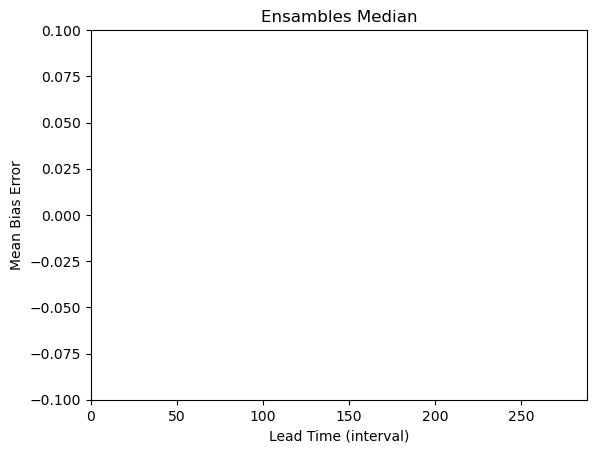

In [26]:
x_ = np.arange(288)
plt.figure()
plt.plot(x_[-e_empirical_1_.shape[1]:], np.mean(e_empirical_1_, axis = 0))
plt.plot(x_[-e_empirical_2_.shape[1]:], np.mean(e_empirical_2_, axis = 0))
plt.plot(x_[-e_empirical_3_.shape[1]:], np.mean(e_empirical_3_, axis = 0))
plt.xlim(0, 288)
plt.ylim(-.1,.1)
plt.title("Ensambles Median")
plt.ylabel("Mean Bias Error")
plt.xlabel("Lead Time (interval)")
plt.show()

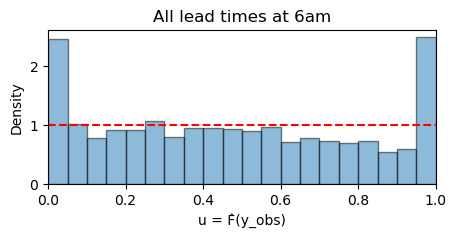

Mean PIT: 0.4743457260692388
Var PIT: 0.10704308467586517


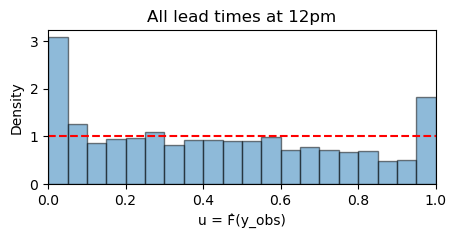

Mean PIT: 0.43169924069844917
Var PIT: 0.10336773062616848


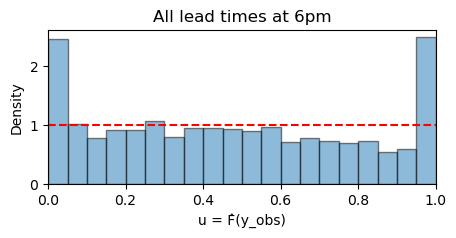

Mean PIT: 0.4264037621969171
Var PIT: 0.10434263376502459


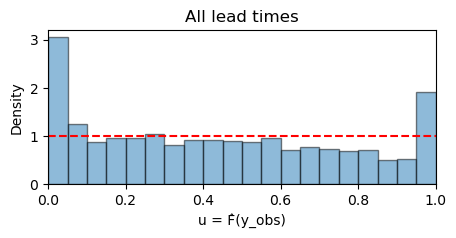

Mean PIT: 0.4361592490094817
Var PIT: 0.1047649910284383


In [36]:
from scipy.stats import kstest

def _plot_PIT(_ax, u_, bins=10, title="PIT Histogram"):
    """
    Make a PIT histogram with a Uniform(0,1) reference line.
    Uses matplotlib, one chart, no explicit colors.
    """

    # histogram as density so the uniform reference is y=1
    _ax.hist(u_, 
            bins=bins, 
            range=(0.0, 1.0), 
            density=True, 
            edgecolor='black', alpha = 0.5)
    
    _ax.axhline(1.0, linestyle='--', color='red')
    _ax.set_xlim(0, 1)
    _ax.set_ylim(0, )

    _ax.set_xlabel("u = F̂(y_obs)")
    _ax.set_ylabel("Density")
    _ax.set_title(title)


# --- Example usage -----------------------------------------------------------
#N cases, each with M forecast samples
#preds[i] are the M samples for case i; obs[i] is the observed value
# N, M = 500, 50
# rng = np.random.default_rng(0)
# preds = rng.normal(0, 1, size=(N, M))
# obs   = rng.normal(0, 1, size=N)
# print(preds.shape, obs.shape)

fig, _ax = plt.subplots(figsize=(5, 2))
_plot_PIT(_ax, u_empirical_3_.flatten(), bins=20, title = 'All lead times at 6am')
plt.show()
print("Mean PIT:", np.mean(u_empirical_3_))          # should be ~0.5
print("Var PIT:", np.var(u_empirical_3_))            # should be ~1/12 ≈ 0.083

fig, _ax = plt.subplots(figsize=(5, 2))
_plot_PIT(_ax, u_empirical_2_.flatten(), bins=20, title = 'All lead times at 12pm')
plt.show()

print("Mean PIT:", np.mean(u_empirical_2_))          # should be ~0.5
print("Var PIT:", np.var(u_empirical_2_))            # should be ~1/12 ≈ 0.083

fig, _ax = plt.subplots(figsize=(5, 2))
_plot_PIT(_ax, u_empirical_3_.flatten(), bins=20, title = 'All lead times at 6pm')
plt.show()

print("Mean PIT:", np.mean(u_empirical_1_))          # should be ~0.5
print("Var PIT:", np.var(u_empirical_1_))            # should be ~1/12 ≈ 0.083

u_empirical_5_ = np.concatenate([u_empirical_1_.flatten(), 
                                 u_empirical_2_.flatten(),
                                 u_empirical_3_.flatten()], axis=0)

fig, _ax = plt.subplots(figsize=(5, 2))
_plot_PIT(_ax, u_empirical_5_.flatten(), bins=20, title = 'All lead times')
plt.show()

print("Mean PIT:", np.mean(u_empirical_5_))          # should be ~0.5
print("Var PIT:", np.var(u_empirical_5_))            # should be ~1/12 ≈ 0.083

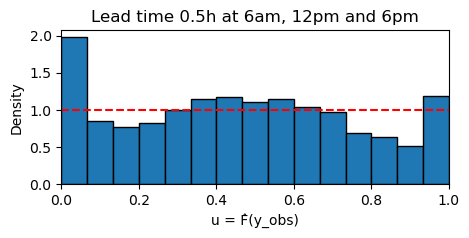

Mean PIT: 0.45940147249928937
Var PIT: 0.08808437327843686


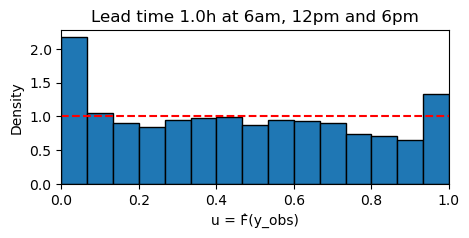

Mean PIT: 0.45653566356192765
Var PIT: 0.09798725474360871


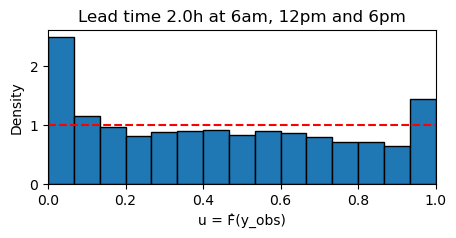

Mean PIT: 0.4448961535681084
Var PIT: 0.10352306045952651


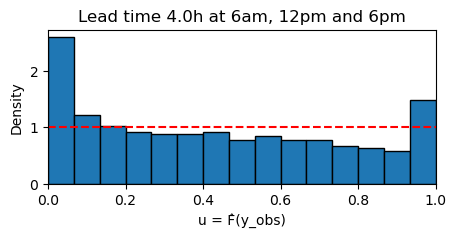

Mean PIT: 0.43345203310245384
Var PIT: 0.10527042092826232


In [30]:
for time in [6, 12, 24, 48]:
    u_empirical_ = np.concatenate([u_empirical_1_[:, time - 1], 
                                   u_empirical_2_[:, time - 1],
                                   u_empirical_3_[:, time - 1]], axis=0)

    fig, _ax = plt.subplots(figsize=(5, 2))
    _plot_PIT(_ax, u_empirical_, bins=15, title = f'Lead time {time/12}h at 6am, 12pm and 6pm')
    plt.show()

    print("Mean PIT:", np.mean(u_empirical_))          # should be ~0.5
    print("Var PIT:", np.var(u_empirical_))            # should be ~1/12 ≈ 0.083

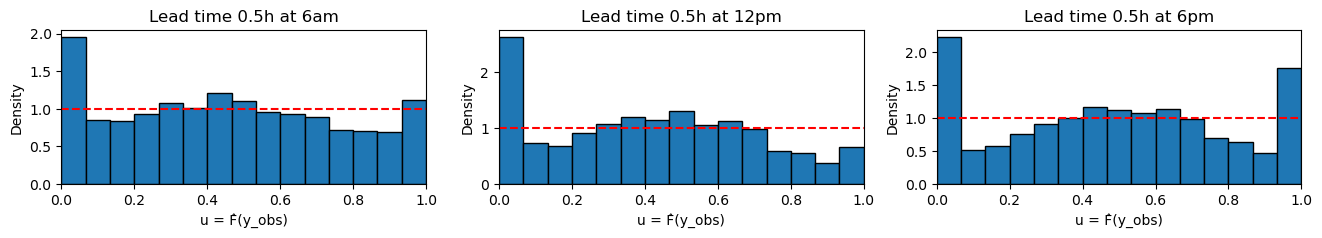

Mean PIT: 0.45716896886009806
Var PIT: 0.09026870567362623
Mean PIT: 0.4159839212465087
Var PIT: 0.08100655023730073
Mean PIT: 0.48542038926391623
Var PIT: 0.09789777904866913


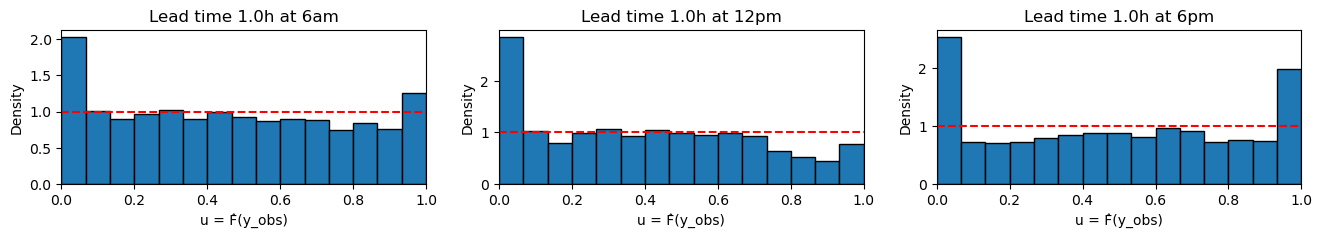

Mean PIT: 0.4604941515046494
Var PIT: 0.09727725861686749
Mean PIT: 0.40368600780889835
Var PIT: 0.0885001476820092
Mean PIT: 0.4861479571561328
Var PIT: 0.11225735156462917


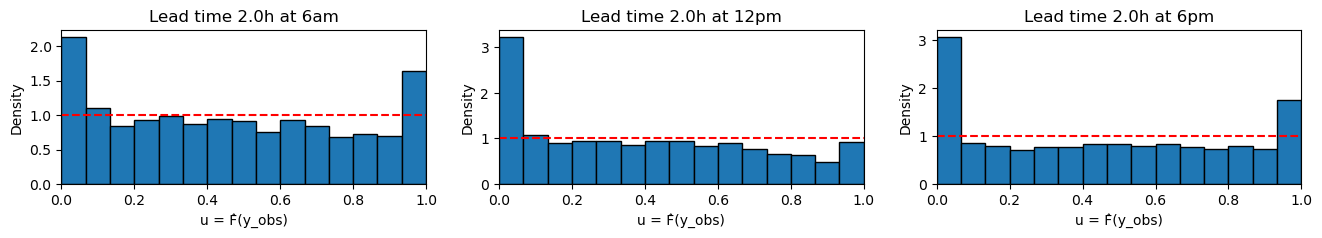

Mean PIT: 0.4641038506815933
Var PIT: 0.10394543447784713
Mean PIT: 0.395649782628675
Var PIT: 0.09625920244032601
Mean PIT: 0.45513376249514265
Var PIT: 0.11565998964135875


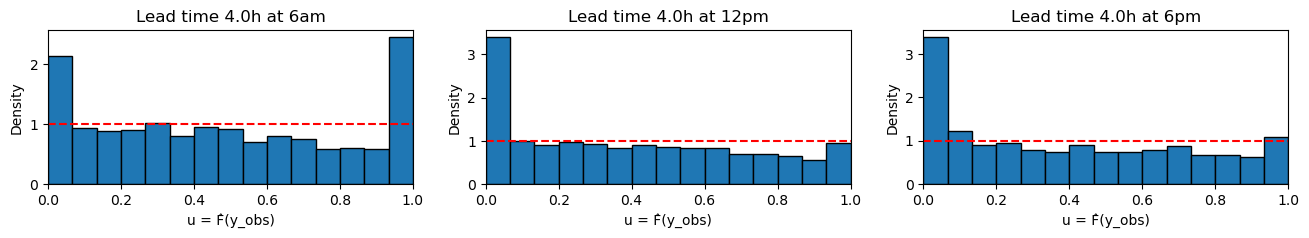

Mean PIT: 0.4846899543597558
Var PIT: 0.11402747753442845
Mean PIT: 0.3946795737432386
Var PIT: 0.09984276206905766
Mean PIT: 0.3999315450993998
Var PIT: 0.10542555074765925


In [32]:
for time in [6, 12, 24, 48]:

    fig, ax = plt.subplots(1, 3, figsize=(16, 2))  # 1 row, 3 columns
    _plot_PIT(ax[0], e_empirical_3_[:, time - 1], bins=15, title = f'Lead time {time/12}h at 6am')
    _plot_PIT(ax[1], e_empirical_2_[:, time - 1], bins=15, title = f'Lead time {time/12}h at 12pm')
    _plot_PIT(ax[2], e_empirical_1_[:, time - 1], bins=15, title = f'Lead time {time/12}h at 6pm')
    plt.show()

    print("Mean PIT:", np.mean(e_empirical_3_[:, time - 1]))          # should be ~0.5
    print("Var PIT:", np.var(e_empirical_3_[:, time - 1]))            # should be ~1/12 ≈ 0.083

    print("Mean PIT:", np.mean(e_empirical_2_[:, time - 1]))          # should be ~0.5
    print("Var PIT:", np.var(e_empirical_2_[:, time - 1]))            # should be ~1/12 ≈ 0.083

    print("Mean PIT:", np.mean(e_empirical_1_[:, time - 1]))          # should be ~0.5
    print("Var PIT:", np.var(e_empirical_1_[:, time - 1]))            # should be ~1/12 ≈ 0.083

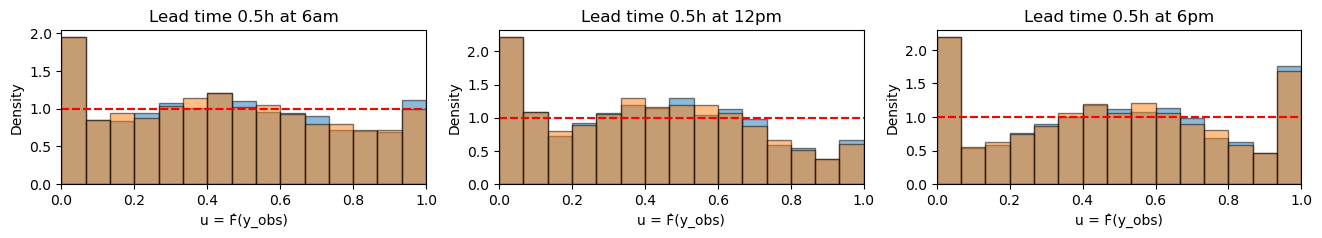

Mean PIT: 0.45704470477094256 0.45336679872053215
Var PIT: 0.09038918298239164 0.08842444430710789
Mean PIT: 0.4184672016781524 0.41518481900880494
Var PIT: 0.07923829305016922 0.07748941287937242
Mean PIT: 0.4852543175217598 0.48144019443434943
Var PIT: 0.09808036208753484 0.09605003773907825


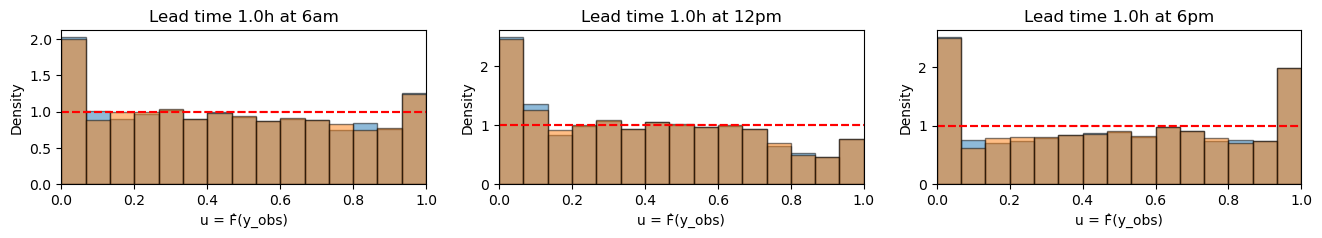

Mean PIT: 0.46016330278761575 0.46175335277348084
Var PIT: 0.09758104453437594 0.09546974731397549
Mean PIT: 0.40580513041472666 0.40797599051563077
Var PIT: 0.08704194922349592 0.08516222078950361
Mean PIT: 0.48613449841239254 0.4873972624696326
Var PIT: 0.11229796854852778 0.10998314046535919


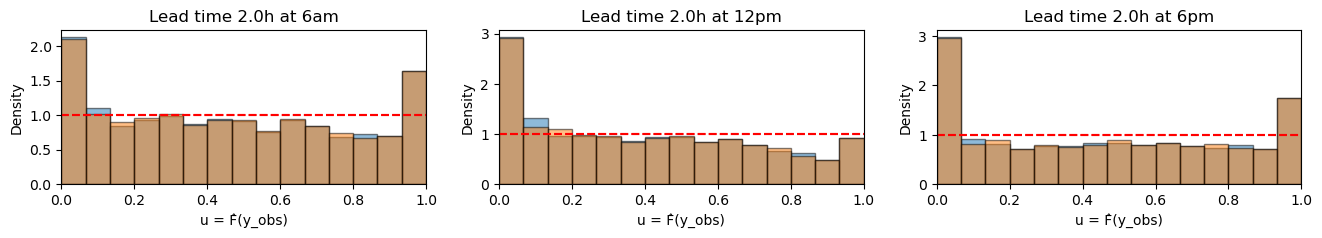

Mean PIT: 0.46370113148325964 0.4652602975441366
Var PIT: 0.10431627224128223 0.10203468096504827
Mean PIT: 0.3974252157913939 0.39970169821542456
Var PIT: 0.09509646998110215 0.09304152772809689
Mean PIT: 0.4556975646459737 0.45728277848734933
Var PIT: 0.11522686507239366 0.11286135264941888


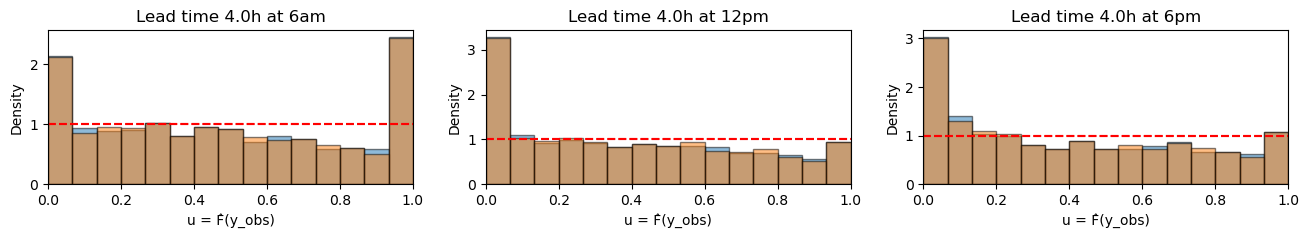

Mean PIT: 0.4842448197417173 0.4841858579825848
Var PIT: 0.11445503158020012 0.11194592387148138
Mean PIT: 0.39509313188247036 0.39602288102921956
Var PIT: 0.09960827155725728 0.09747912037428028
Mean PIT: 0.402772265945819 0.40359775386638563
Var PIT: 0.10365519918238326 0.10152760545560739


In [40]:
for time in [6, 12, 24, 48]:

    fig, ax = plt.subplots(1, 3, figsize=(16, 2))  # 1 row, 3 columns
    _plot_PIT(ax[0], u_empirical_3_[:, time - 1], bins=15, title = f'Lead time {time/12}h at 6am')
    _plot_PIT(ax[0], e_empirical_3_[:, time - 1], bins=15, title = f'Lead time {time/12}h at 6am')

    _plot_PIT(ax[1], u_empirical_2_[:, time - 1], bins=15, title = f'Lead time {time/12}h at 12pm')
    _plot_PIT(ax[1], e_empirical_2_[:, time - 1], bins=15, title = f'Lead time {time/12}h at 12pm')

    _plot_PIT(ax[2], u_empirical_1_[:, time - 1], bins=15, title = f'Lead time {time/12}h at 6pm')
    _plot_PIT(ax[2], e_empirical_1_[:, time - 1], bins=15, title = f'Lead time {time/12}h at 6pm')

    plt.show()

    # should be ~0.5
    # should be ~1/12 ≈ 0.083

    print("Mean PIT:", np.mean(u_empirical_3_[:, time - 1]), np.mean(e_empirical_3_[:, time - 1]))     
    print("Var PIT:", np.var(u_empirical_3_[:, time - 1]), np.var(e_empirical_3_[:, time - 1]))         

    print("Mean PIT:", np.mean(u_empirical_2_[:, time - 1]), np.mean(e_empirical_2_[:, time - 1]))       
    print("Var PIT:", np.var(u_empirical_2_[:, time - 1]), np.var(e_empirical_2_[:, time - 1]))         

    print("Mean PIT:", np.mean(u_empirical_1_[:, time - 1]), np.mean(e_empirical_1_[:, time - 1]))       
    print("Var PIT:", np.var(u_empirical_1_[:, time - 1]), np.var(e_empirical_1_[:, time - 1]))       